# Model Training and Evaluation

In this notebook, we will train and evaluate various regression models on the Algerian Forest Fires dataset. The workflow includes data preprocessing, feature selection, and applying different regression techniques such as Linear Regression, Lasso, Ridge, and ElasticNet. We will also assess model performance using appropriate evaluation metrics.

In [8]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# Reading the dataset
df = pd.read_csv("Forest_fire_updated_dataset.csv")
df.head()

,Unnamed: 0,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [5]:
# Drop the extra column 
df = df.drop("Unnamed: 0", axis=1)

In [7]:
df.head(10)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
5,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0
6,7,6,2012,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0
7,8,6,2012,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,fire,0
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire,0
9,10,6,2012,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0


In [5]:
# Encoding of classes to 0 and 1
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0, 1)

In [6]:
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [7]:
# drop the column we don't need 
df.drop(["month", "year", "day"], inplace=True, axis=1)

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
# selecting Dependent and independent features
X = df.drop("FWI", axis=1)
Y = df["FWI"]

In [10]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [11]:
# split the dataset in train and test
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25, random_state=42)


In [12]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

<Axes: >

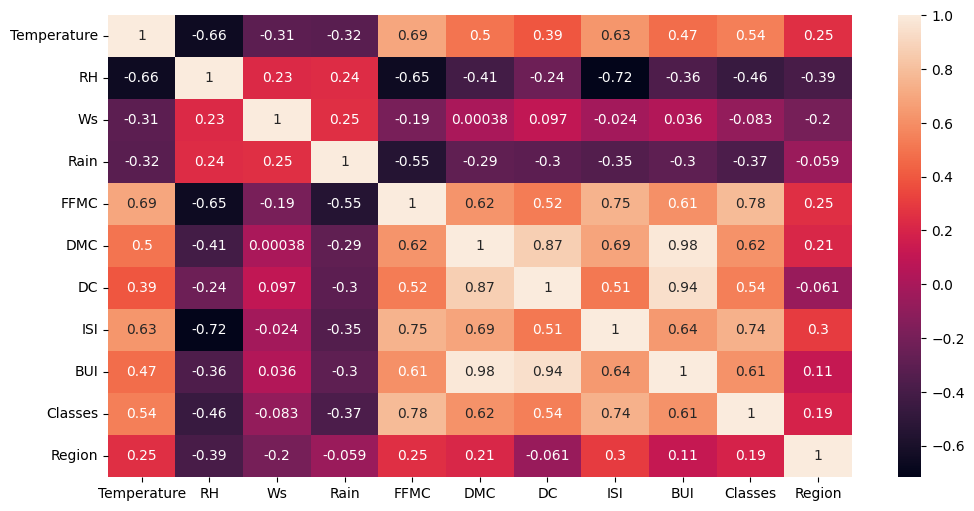

In [13]:
# check for correlation
corr = X_train.corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True)

In [14]:

def correlation(dataset, threshold):
    ''' 
    Function that returns the features that are correlated, depending upon threshold
    '''
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
         if abs(corr_matrix.iloc[i,j]) > threshold:
            col_name = corr_matrix.columns[i]
            col_corr.add(col_name)
    return col_corr        

In [15]:
# Getting the features which have collinearity more than 85%
corr_features = correlation(X_train, 0.85)
corr_features


{'BUI', 'DC'}

In [16]:
# Deleting the features
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)

In [17]:
X_train.shape

(182, 9)

In [18]:
# scaling of X_train and X_test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
Y_pred = regression.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test, Y_pred)

In [23]:
print("Mean absolute error of the model", mae)
print("Mean square error of the model", mse)
print("Root Mean square error of the model", rmse)
print("R square of the model: ", score)

Mean absolute error of the model 0.5468236465249987
Mean square error of the model 0.67427668737916
Root Mean square error of the model 0.8211435242265265
R square of the model:  0.9847657384266951


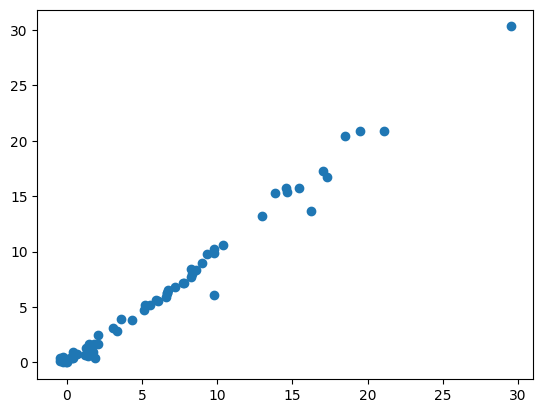

In [24]:
plt.scatter(Y_pred, Y_test )

# Lasso Regression

Mean absolute error of the model 1.133175994914409
Mean square error of the model 2.2483458918974764
Root Mean square error of the model 1.4994485292591662
R square of the model:  0.9492020263112388


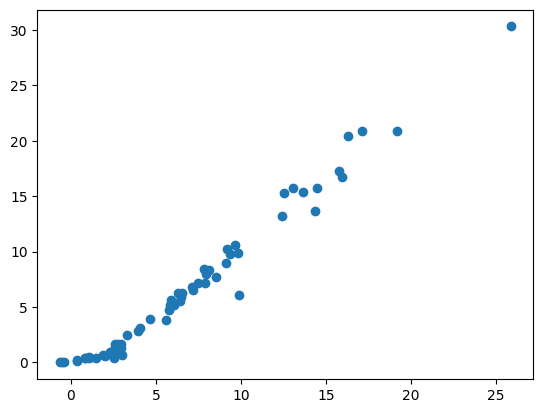

In [25]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train, Y_train)
Y_pred = lasso.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test, Y_pred)
plt.scatter(Y_pred, Y_test)

print("Mean absolute error of the model", mae)
print("Mean square error of the model", mse)
print("Root Mean square error of the model", rmse)
print("R square of the model: ", score)

# Ridge regression

Mean absolute error of the model 0.5642305340105704
Mean square error of the model 0.6949198918152095
Root Mean square error of the model 0.833618552945656
R square of the model:  0.9842993364555512


/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


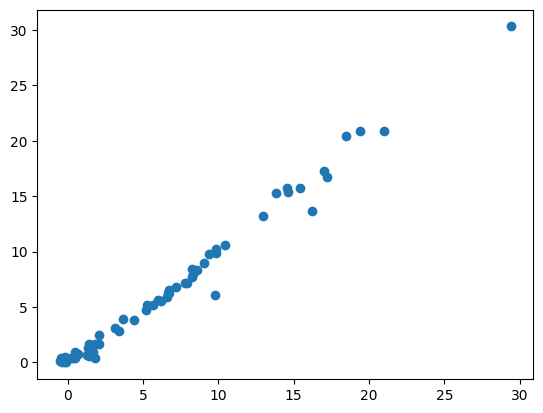

In [26]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train, Y_train)
Y_pred = ridge.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test, Y_pred)
plt.scatter(Y_pred, Y_test)

print("Mean absolute error of the model", mae)
print("Mean square error of the model", mse)
print("Root Mean square error of the model", rmse)
print("R square of the model: ", score)

# Ridge Cross-Validation 

Mean absolute error of the model 0.5642305340105704
Mean square error of the model 0.6949198918152095
Root Mean square error of the model 0.833618552945656
R square of the model:  0.9842993364555512


/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Krish Naik)/venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/palak/Documents/Machine learning bootcamp(Kris

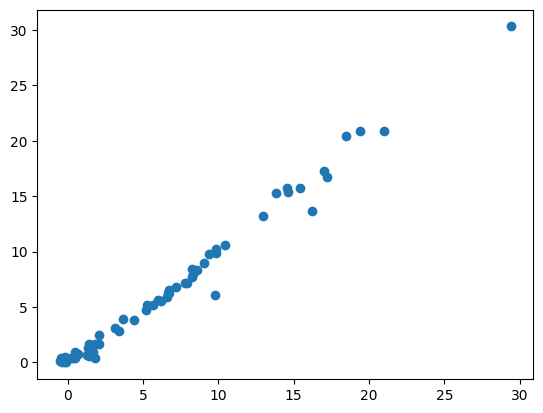

In [27]:
from sklearn.linear_model import RidgeCV
ridgecv= RidgeCV(cv=5)
ridgecv.fit(X_train, Y_train)
Y_pred = ridgecv.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test, Y_pred)
plt.scatter(Y_pred, Y_test)

print("Mean absolute error of the model", mae)
print("Mean square error of the model", mse)
print("Root Mean square error of the model", rmse)
print("R square of the model: ", score)


Mean absolute error of the model 0.6199701158263436
Mean square error of the model 0.7924995554743638
Root Mean square error of the model 0.8902244410677365
R square of the model:  0.9820946715928274


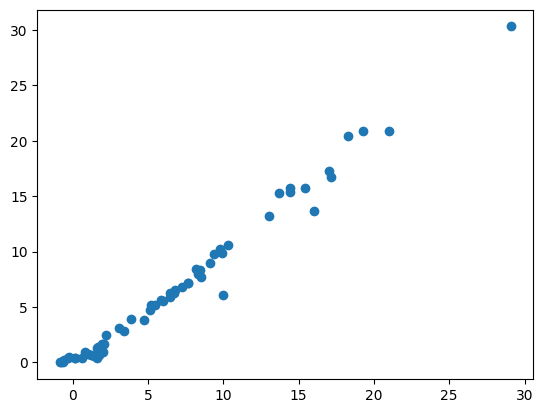

In [28]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5)
lasso.fit(X_train, Y_train)
Y_pred = lasso.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test, Y_pred)
plt.scatter(Y_pred, Y_test)

print("Mean absolute error of the model", mae)
print("Mean square error of the model", mse)
print("Root Mean square error of the model", rmse)
print("R square of the model: ", score)

# ElasticNet Cross validation

Mean absolute error of the model 0.65759467314309
Mean square error of the model 0.8222830416276261
Root Mean square error of the model 0.9067982364493361
R square of the model:  0.9814217587854941


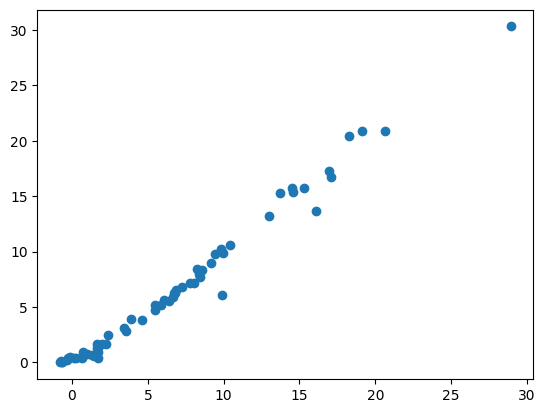

In [29]:
from sklearn.linear_model import ElasticNetCV
elasticnet = ElasticNetCV(cv=5)
elasticnet.fit(X_train, Y_train)
Y_pred = elasticnet.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
score = r2_score(Y_test, Y_pred)
plt.scatter(Y_pred, Y_test)

print("Mean absolute error of the model", mae)
print("Mean square error of the model", mse)
print("Root Mean square error of the model", rmse)
print("R square of the model: ", score)

## The best performance is given by linear regression, but since there's risk of overfitting with plan linear regression, since performance of ridge is very close to linear regression, we'll consider Ridge regression our best and optimal model, this way we'll avoid overfitting...

In [37]:
import pickle
pickle.dump(scaler, open("Scaler.pkl", "wb"))
pickle.dump(ridge, open("Ridge_regression.pkl", "wb"))

In [31]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [35]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [38]:
! git add .


In [39]:
! git status

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   model_training.ipynb

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../Data Analysiss/commanDoubts.ipynb
	modified:   ../EDA/Goggle_playstore.ipynb
	modified:   ../Feature engineering/Encoding.ipynb
	modified:   ../Python_basics/data_structures/test.ipynb
	modified:   ../Regression/polynomial_regression.ipynb
	deleted:    ../regression practical/Algerian_forest_fires_dataset_UPDATE.csv
	modified:   ../regression practical/feature_selection.ipynb



In [40]:
! git commit -m "Pickling"

[main 3a65454] Pickling
 1 file changed, 790 insertions(+), 195 deletions(-)
